# MESACLIP + FOSI Sea Ice Concentration Validation - Spatial Maps
## Compare model SIC (MESACLIP ensemble, FOSI hindcast) against NSIDC CDR obs, over the EngressNet ML regional domain

Adapted from `mesaclip_validate_sic_spatial.ipynb` to (1) add FOSI as a second model alongside MESACLIP and
(2) use the actual ML regional domain (`DEFAULT_BBOX` in `functions_engressnet.py`: lat 60-80N, lon 170-220E)
instead of the ad hoc Alaska box the original notebook used.

In [1]:
import numpy as np
import xarray as xr
from glob import glob
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.pyplot as plt
import matplotlib.path as mpath

## Regional domain
Matches the ML training/eval domain; see `Version4/functions_engressnet.py:48` (`DEFAULT_BBOX`).

In [2]:
# lon in degrees_east, lat in degrees_north -- mirrors functions_engressnet.DEFAULT_BBOX
BBOX = {"lon_min": -190, "lon_max": -140, "lat_min": 60, "lat_max": 80}

def bbox_ij_slice(tlat, tlon, bbox):
    """Index-space (j, i) bounding box enclosing bbox on a curvilinear (2D lat/lon) grid.
    Longitude is normalized to [0, 360) on both sides of the comparison so a bbox crossing
    the dateline (like this one, 170E-220E) works the same as functions_engressnet.py's masking."""
    lon_min = bbox["lon_min"] % 360
    lon_max = bbox["lon_max"] % 360
    tlon360 = tlon % 360
    mask = (tlat >= bbox["lat_min"]) & (tlat <= bbox["lat_max"]) & (tlon360 >= lon_min) & (tlon360 <= lon_max)
    jj, ii = np.where(mask.values if hasattr(mask, "values") else mask)
    return slice(int(jj.min()), int(jj.max()) + 1), slice(int(ii.min()), int(ii.max()) + 1)

def fill_nan_coord(da):
    """MESACLIP/FOSI set TLAT/TLON themselves to NaN over all-land computational blocks
    (not just the data), which pcolormesh/contour reject as coordinate input. Since aice is
    NaN at exactly those same cells already (real land there, nothing to plot), it's safe to
    fill the coordinate gaps from nearby valid neighbors -- the mesh cell lands in roughly the
    right place but stays uncolored (NaN data), same as if TLAT/TLON had never been masked."""
    dims = da.dims
    return da.ffill(dims[0]).bfill(dims[0]).ffill(dims[1]).bfill(dims[1])

In [3]:
# decades compared across all 3 sources -- FOSI starts 1958, CDR starts 1979, so these three
# decades are the ones with full coverage in MESACLIP, FOSI, *and* CDR alike
DECADES = [1980, 2000, 2010]

## Load MESACLIP data
- CESM-HR (ne120_t12) 9-member ensemble, monthly `aice` (%)
- historical 1920-2005 (`/gdex/data/d651007`) spliced with RCP8.5 2006-2100 (`/gdex/data/d651009`), matched by ensemble suffix
- pulled raw rather than from the old duvivier-preprocessed file, which lives in a `cgd`-group-only
  directory (`/glade/campaign/cgd/ppc/duvivier/...`) this account no longer has read access to

In [4]:
dir_hist = "/gdex/data/d651007"
dir_rcp85 = "/gdex/data/d651009"

hist_dirs = sorted(glob(f"{dir_hist}/*ihesp-hires*"))
rcp85_dirs = sorted(glob(f"{dir_rcp85}/*ihesp-hires*"))
# both dir names end in the same 3-digit ensemble suffix (e.g. "...002") -- match on that
member_ids = [d[-3:] for d in hist_dirs]
assert member_ids == [d[-3:] for d in rcp85_dirs], "historical/RCP8.5 member ordering does not match"
print("MESACLIP members:", member_ids)

MESACLIP members: ['002', '003', '004', '005', '006', '007', '008', '009', '010']


In [5]:
# open each member (historical + RCP8.5), crop to the regional bbox, then concat members.
# Cropping right after opening (while still dask-lazy) keeps this from ever materializing
# the full 3600x2400 global grid for 19 files/member.
mesa_members = []
nj_sl_mesa = ni_sl_mesa = None

for hdir, rdir in zip(hist_dirs, rcp85_dirs):
    hist_files = sorted(glob(f"{hdir}/ice/proc/tseries/month_1/*.aice.*.nc"))
    rcp85_files = sorted(glob(f"{rdir}/ice/proc/tseries/month_1/*.aice.*.nc"))
    ds_h = xr.open_mfdataset(hist_files, combine="by_coords")
    ds_r = xr.open_mfdataset(rcp85_files, combine="by_coords")
    if nj_sl_mesa is None:
        nj_sl_mesa, ni_sl_mesa = bbox_ij_slice(ds_h.TLAT, ds_h.TLON, BBOX)
    ds_h = ds_h[["aice", "tarea", "TLAT", "TLON"]].isel(nj=nj_sl_mesa, ni=ni_sl_mesa)
    ds_r = ds_r[["aice", "tarea", "TLAT", "TLON"]].isel(nj=nj_sl_mesa, ni=ni_sl_mesa)
    mesa_members.append(xr.concat([ds_h, ds_r], dim="time"))

ds_mesaclip = xr.concat(mesa_members, dim="member_id")
ds_mesaclip = ds_mesaclip.assign_coords(member_id=member_ids)
# TLAT/TLON are identical across members, so xr.concat's default compat check
# leaves them without a member_id dim at all (unlike aice, which does vary) --
# use them directly rather than trying to isel(member_id=0)
# also fill the NaN'd-out land-block coordinates so pcolormesh/contour can use them (see fill_nan_coord)
mesa_lat2d = fill_nan_coord(ds_mesaclip.TLAT.isel(member_id=0))
mesa_lon2d = fill_nan_coord(ds_mesaclip.TLON.isel(member_id=0))
ds_mesaclip

/glade/derecho/scratch/skygale/tmp/ipykernel_57785/484332151.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_h = xr.open_mfdataset(hist_files, combine="by_coords")
/glade/derecho/scratch/skygale/tmp/ipykernel_57785/484332151.py:11: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_r = xr.open_mfdataset(r

<xarray.Dataset> Size: 32GB
Dimensions:    (member_id: 9, time: 2172, nj: 434, ni: 474)
Coordinates:
  * member_id  (member_id) <U3 108B '002' '003' '004' ... '008' '009' '010'
  * time       (time) object 17kB 1920-02-01 00:00:00 ... 2101-01-01 00:00:00
    TLAT       (member_id, nj, ni) float32 7MB 60.2 60.2 60.2 ... 69.12 69.09
    TLON       (member_id, nj, ni) float32 7MB 164.7 164.8 164.9 ... 240.1 240.2
    ULON       (member_id, nj, ni) float32 7MB 164.7 164.9 ... -119.8 -119.8
    ULAT       (member_id, nj, ni) float32 7MB 60.24 60.23 60.23 ... 69.11 69.08
Dimensions without coordinates: nj, ni
Data variables:
    aice       (member_id, time, nj, ni) float32 16GB dask.array<chunksize=(1, 1, 434, 474), meta=np.ndarray>
    tarea      (member_id, time, nj, ni) float32 16GB dask.array<chunksize=(1, 120, 434, 474), meta=np.ndarray>
Attributes:
    title:        b.e13.BHISTC5.ne120_t12.cesm-ihesp-hires1.0.30-1920-2100.002
    contents:     Diagnostic and Prognostic Variables
    source:       sea ice model: Community Ice Code (CICE)
    comment:      All years have exactly 365 days
    comment2:     File written on model date 19200201
    comment3:     seconds elapsed into model date:      0
    conventions:  CF-1.0
    history:      This dataset was created on 2020-11-06 at 11:00

## Load FOSI data
- CESM-HR (t13), JRA55-forced, single realization, monthly `aice` (fraction 0-1)
- same native tripole grid as MESACLIP (confirmed identical TLAT/TLON), so shares the same crop indices

In [6]:
dir_fosi = "/glade/campaign/cgd/oce/projects/FOSI_BGC/HR/g.e22.TL319_t13.G1850ECOIAF_JRA_HR.4p2z.001/ice/proc/tseries/month_1"
fosi_files = sorted(glob(f"{dir_fosi}/*.aice.*.nc"))
ds_fosi = xr.open_mfdataset(fosi_files, combine="by_coords")

nj_sl_fosi, ni_sl_fosi = bbox_ij_slice(ds_fosi.TLAT, ds_fosi.TLON, BBOX)
ds_fosi = ds_fosi[["aice", "tarea", "TLAT", "TLON"]].isel(nj=nj_sl_fosi, ni=ni_sl_fosi)
fosi_lat2d = fill_nan_coord(ds_fosi.TLAT)
fosi_lon2d = fill_nan_coord(ds_fosi.TLON)
ds_fosi

/glade/derecho/scratch/skygale/tmp/ipykernel_57785/2127779694.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_fosi = xr.open_mfdataset(fosi_files, combine="by_coords")


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 768, nj: 434, ni: 478)
Coordinates:
  * time     (time) object 6kB 1958-02-01 00:00:00 ... 2022-01-01 00:00:00
    TLAT     (nj, ni) float32 830kB dask.array<chunksize=(434, 478), meta=np.ndarray>
    TLON     (nj, ni) float32 830kB dask.array<chunksize=(434, 478), meta=np.ndarray>
    ULON     (nj, ni) float32 830kB dask.array<chunksize=(434, 478), meta=np.ndarray>
    ULAT     (nj, ni) float32 830kB dask.array<chunksize=(434, 478), meta=np.ndarray>
Dimensions without coordinates: nj, ni
Data variables:
    aice     (time, nj, ni) float32 637MB dask.array<chunksize=(1, 434, 478), meta=np.ndarray>
    tarea    (time, nj, ni) float32 637MB dask.array<chunksize=(12, 434, 478), meta=np.ndarray>
Attributes:
    title:             g.e22.TL319_t13.G1850ECOIAF_JRA_HR.4p2z.001
    contents:          Diagnostic and Prognostic Variables
    source:            Los Alamos Sea Ice Model (CICE) Version 5
    time_period_freq:  month_1
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    comment:           All years have exactly 365 days
    comment2:          File written on model date 19580201
    comment3:          seconds elapsed into model date:      0
    conventions:       CF-1.0
    history:           This dataset was created on 2022-07-17 at 19:38
    io_flavor:         io_pio

In [7]:
# put FOSI's fraction (0-1) on the same 0-100 percent scale as MESACLIP/CDR
ds_fosi["aice"] = ds_fosi["aice"] * 100

## Load CDR satellite SIC data
- daily NH data on 25km x 25km EASE grid
- crop to the bbox *before* resampling to monthly -- doing it after means averaging ~50x more
  data than needed and is dramatically slower

In [8]:
dir_grid = "/glade/campaign/cesm/development/pcwg/ssmi/"
ds_grid = xr.open_mfdataset(dir_grid + "grid_nh.nc", decode_times=False)
nj_sl_cdr, ni_sl_cdr = bbox_ij_slice(ds_grid.latitude, ds_grid.longitude, BBOX)

cdr_lat2d = ds_grid.latitude.isel(ygrid=nj_sl_cdr, xgrid=ni_sl_cdr)
cdr_lon2d = ds_grid.longitude.isel(ygrid=nj_sl_cdr, xgrid=ni_sl_cdr)

In [9]:
dir_in = "/glade/campaign/cesm/development/pcwg/ssmi/CDR/"
file_in = "cdr_seaice_conc_daily_nh.cdr.noleap.19790101-20211231.nc"
ds_cdr = xr.open_dataset(dir_in + file_in, chunks={"time": 365})

# reassign a proper noleap cftime time axis (the raw file's time coordinate isn't usable directly)
dates_noleap = xr.date_range(start="1979-01-01", end="2021-12-31", freq="D", calendar="noleap", use_cftime=True)
ds_cdr["time"] = dates_noleap

# grid_nh.nc's (ygrid, xgrid) and the data file's (jdim, idim) are the same native EASE grid
# in the same index order, just labeled differently -- so the bounding box computed above
# from the grid file applies directly here
sic_cdr = ds_cdr.cdr_seaice_conc_daily.isel(jdim=nj_sl_cdr, idim=ni_sl_cdr)

In [10]:
sic_cdr_monthly = sic_cdr.resample(time="ME").mean()

### Split out March and September

In [11]:
sic_cdr_mar = sic_cdr_monthly.sel(time=sic_cdr_monthly.time.dt.month == 3)
sic_cdr_sep = sic_cdr_monthly.sel(time=sic_cdr_monthly.time.dt.month == 9)

mesa_mar = ds_mesaclip.aice.sel(time=ds_mesaclip.time.dt.month == 3)
mesa_sep = ds_mesaclip.aice.sel(time=ds_mesaclip.time.dt.month == 9)

fosi_mar = ds_fosi.aice.sel(time=ds_fosi.time.dt.month == 3)
fosi_sep = ds_fosi.aice.sel(time=ds_fosi.time.dt.month == 9)

## Compute decadal means
- MESACLIP: mean over ensemble members *and* over each decade's years
- FOSI: single realization, mean over each decade's years
- CDR: mean over each decade's years

In [12]:
def decade_mean(da, decade, extra_mean_dims=()):
    yrs = list(range(decade, decade + 10))
    sub = da.sel(time=da.time.dt.year.isin(yrs))
    dims = ("time",) + tuple(extra_mean_dims)
    return sub.mean(dim=dims).compute()

In [13]:
# this cell does all the actual data reading -- ~5-8 minutes (9 MESACLIP members x 2 months
# x 3 decades dominate the runtime; FOSI and CDR are each much faster since they're single-realization)
mesa_mar_decades = {d: decade_mean(mesa_mar, d, extra_mean_dims=("member_id",)) for d in DECADES}
mesa_sep_decades = {d: decade_mean(mesa_sep, d, extra_mean_dims=("member_id",)) for d in DECADES}

fosi_mar_decades = {d: decade_mean(fosi_mar, d) for d in DECADES}
fosi_sep_decades = {d: decade_mean(fosi_sep, d) for d in DECADES}

cdr_mar_decades = {d: decade_mean(sic_cdr_mar, d) for d in DECADES}
cdr_sep_decades = {d: decade_mean(sic_cdr_sep, d) for d in DECADES}

## Plot maps by decade and source to compare

In [14]:
# set output directory
import os
dir_out = "/glade/work/skygale/_projects/SeaIceDownscaling/Version4/saved_figs/mesaclip_fosi_validation/"
os.makedirs(dir_out, exist_ok=True)

In [15]:
# colors and levels for SIC
cmap_in = cmocean.cm.ice
vmin_in = 0
vmax_in = 100
ticks_in = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
units_in = "%"

# ice edge contour level (15% SIC, standard definition)
levels_edge = [15, 100]

lon_avg = (BBOX["lon_min"] + BBOX["lon_max"]) / 2
lon_min_360 = BBOX["lon_min"] % 360
lon_max_360 = BBOX["lon_max"] % 360

### Create SIC mean plots

In [16]:
def rounded_boundary_path(proj, lon_min, lon_max, lat_min, lat_max, n=50):
    """Quadrilateral Axes-boundary path (in projected coords) tracing the given lon/lat box.
    Under a polar projection this comes out curved along the lat edges, so panels clipped to
    it read as "map-shaped" rather than a plain rectangular Axes frame."""
    lons = np.concatenate([
        np.linspace(lon_min, lon_max, n),
        np.full(n, lon_max),
        np.linspace(lon_max, lon_min, n),
        np.full(n, lon_min),
    ])
    lats = np.concatenate([
        np.full(n, lat_min),
        np.linspace(lat_min, lat_max, n),
        np.full(n, lat_max),
        np.linspace(lat_max, lat_min, n),
    ])
    pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
    return mpath.Path(pts[:, :2])


def plot_decade_maps(month_label, sources, fout):
    """sources: list of (lon2d, lat2d, decades_dict, label) tuples, one row per source."""
    nrow, ncol = len(sources), len(DECADES)
    proj = ccrs.NorthPolarStereo(central_longitude=lon_avg)
    boundary_path = rounded_boundary_path(proj, lon_min_360, lon_max_360, BBOX["lat_min"], BBOX["lat_max"])

    fig, axes = plt.subplots(
        nrow, ncol, figsize=(3.6 * ncol, 3.7 * nrow),
        subplot_kw={"projection": proj},
    )

    for row, (lon2d, lat2d, decades_dict, label) in enumerate(sources):
        for col, d in enumerate(DECADES):
            ax = axes[row, col]
            cs = ax.pcolormesh(lon2d, lat2d, decades_dict[d], vmin=vmin_in, vmax=vmax_in,
                                cmap=cmap_in, transform=ccrs.PlateCarree())
            ax.set_extent([lon_min_360, lon_max_360, BBOX["lat_min"], BBOX["lat_max"]], crs=ccrs.PlateCarree())
            ax.set_boundary(boundary_path, transform=proj)
            ax.add_feature(cfeature.LAND, zorder=50, edgecolor="k")
            ax.gridlines(draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            ax.set_title(f"{label} {d}-{d+9}", fontsize=13)

    # tight gaps between panels -- the default spacing leaves large gaps here because each
    # geo axes shrinks to its data extent, but the grid cell around it stays full-sized
    fig.subplots_adjust(wspace=0.05, hspace=0.15, top=0.90, bottom=0.12)
    fig.suptitle(f"Average {month_label} SIC", fontsize=16, y=0.97)

    cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, ticks=ticks_in, orientation="horizontal")
    cbar.ax.set_xticklabels([str(t) for t in ticks_in])
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(units_in, fontsize=11)

    fig.savefig(dir_out + fout + ".png", bbox_inches="tight", dpi=200)
    return fig


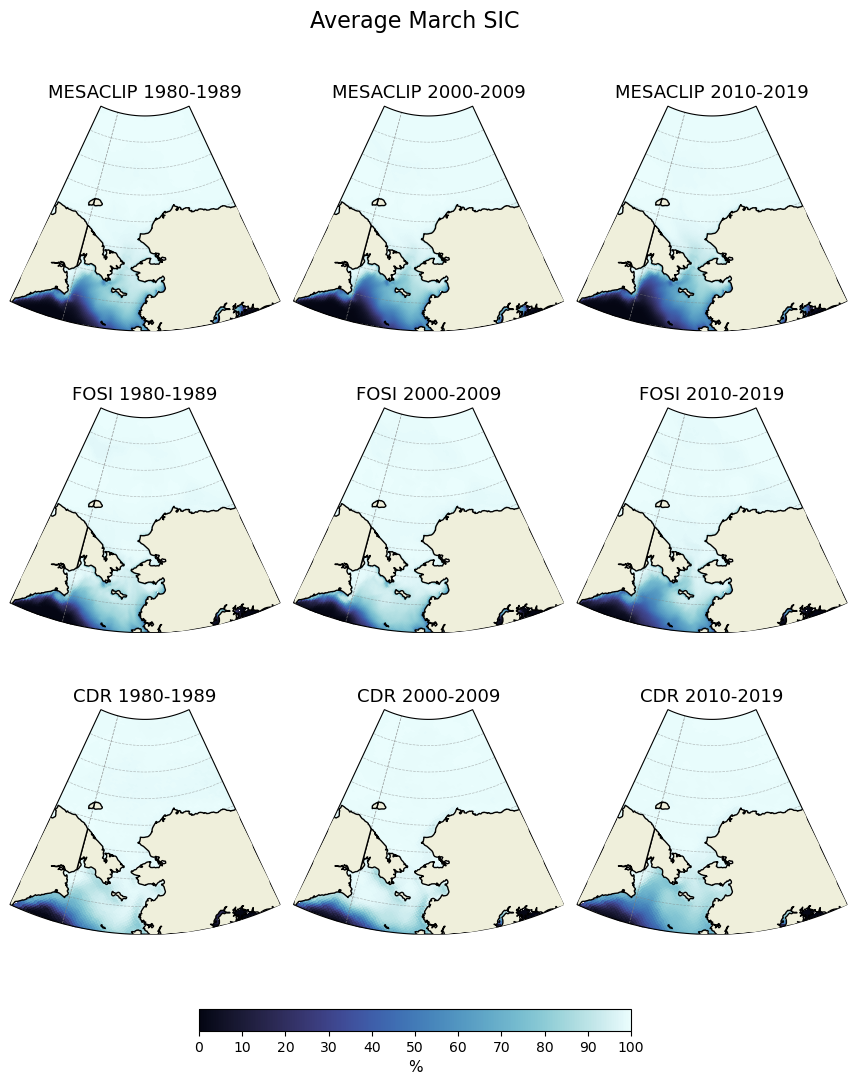

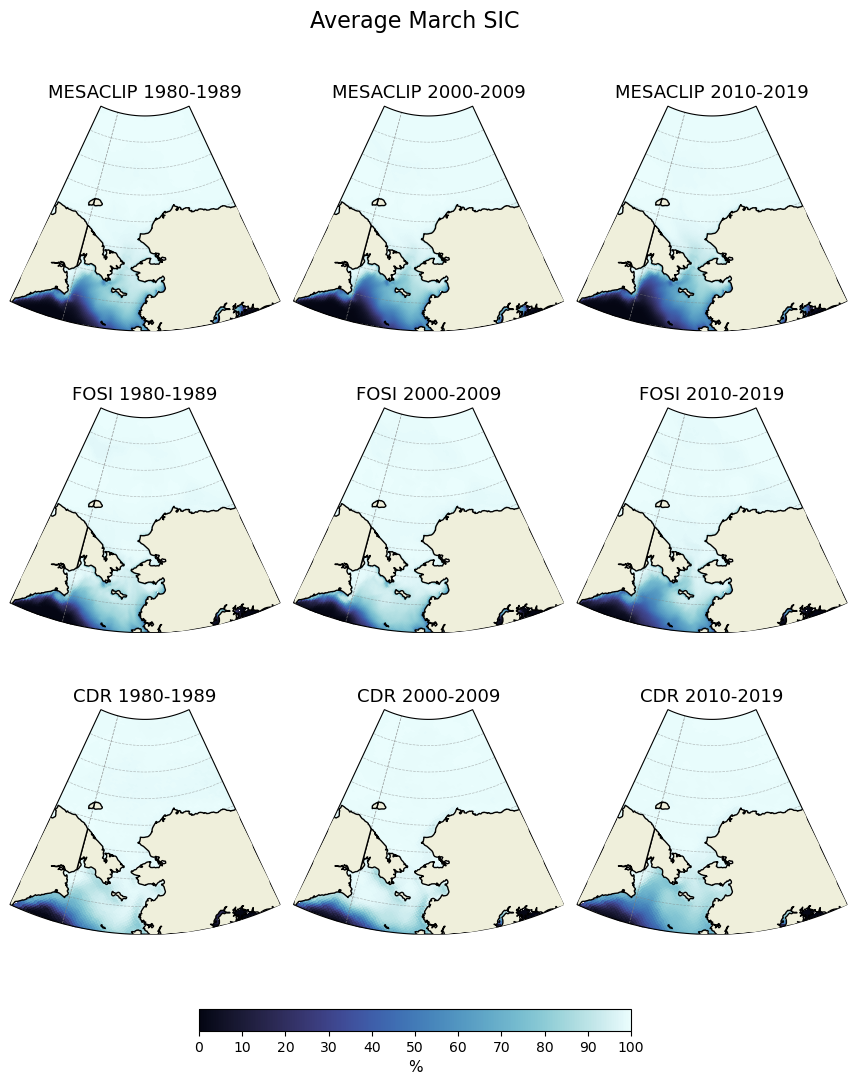

In [17]:
# march
plot_decade_maps(
    "March",
    sources=[
        (mesa_lon2d, mesa_lat2d, mesa_mar_decades, "MESACLIP"),
        (fosi_lon2d, fosi_lat2d, fosi_mar_decades, "FOSI"),
        (cdr_lon2d, cdr_lat2d, cdr_mar_decades, "CDR"),
    ],
    fout="mesaclip_fosi_march_spatial_validation",
)

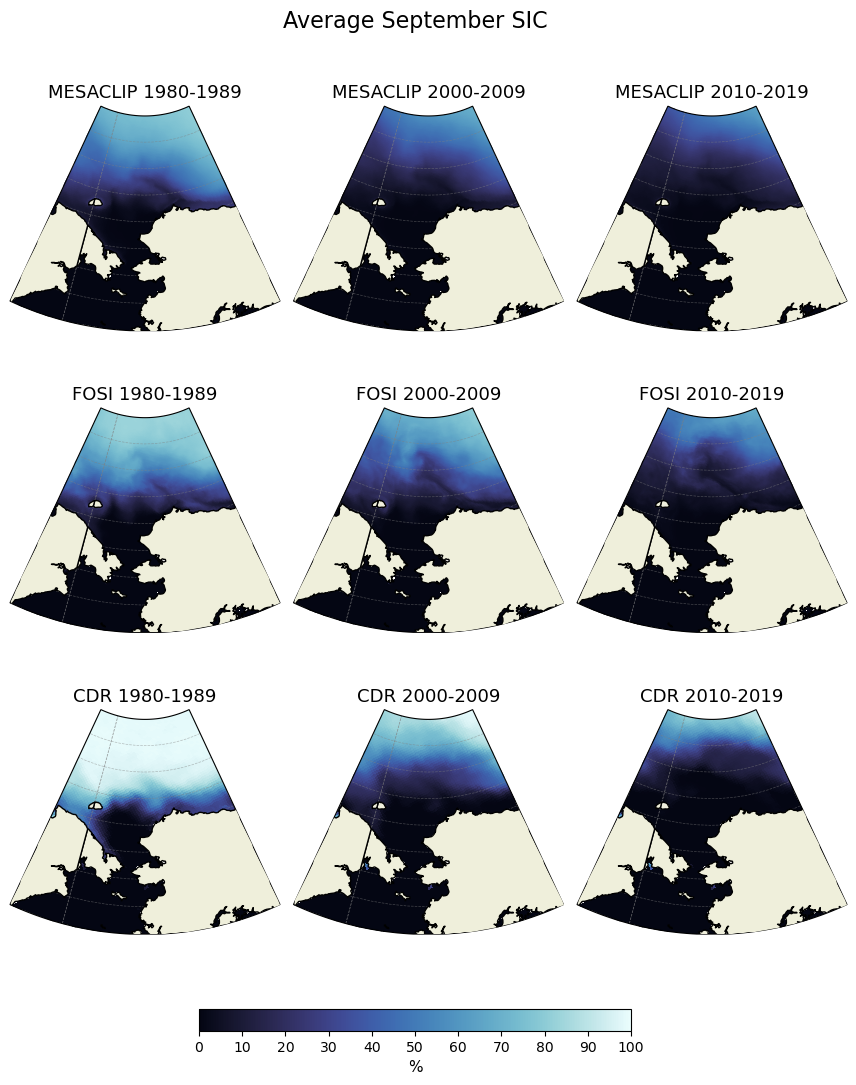

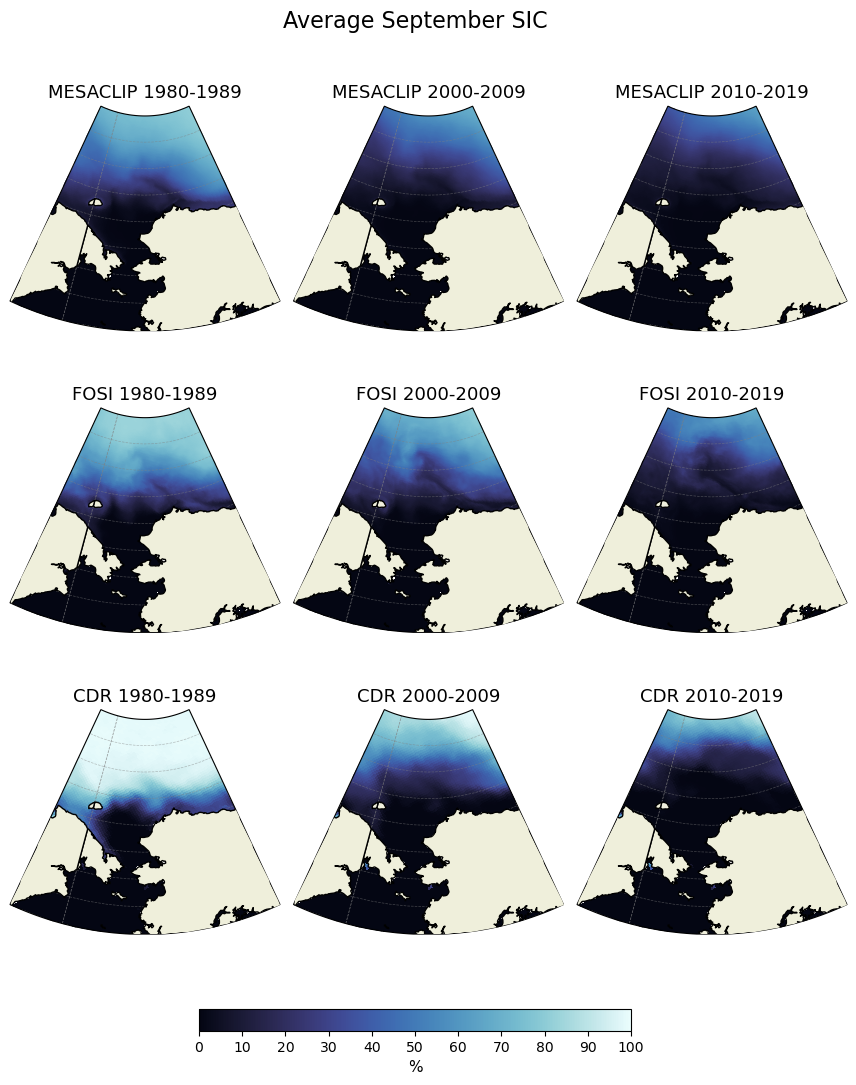

In [18]:
# september
plot_decade_maps(
    "September",
    sources=[
        (mesa_lon2d, mesa_lat2d, mesa_sep_decades, "MESACLIP"),
        (fosi_lon2d, fosi_lat2d, fosi_sep_decades, "FOSI"),
        (cdr_lon2d, cdr_lat2d, cdr_sep_decades, "CDR"),
    ],
    fout="mesaclip_fosi_september_spatial_validation",
)

### Create ice edge (15% SIC) comparison plots

In [21]:
def plot_ice_edges(month_label, edge_sources, fout):
    """edge_sources: list of (lon2d, lat2d, decades_dict, color, label) tuples, overlaid per panel."""
    early_d, late_d = DECADES[0], DECADES[-1]
    proj = ccrs.NorthPolarStereo(central_longitude=lon_avg)
    boundary_path = rounded_boundary_path(proj, lon_min_360, lon_max_360, BBOX["lat_min"], BBOX["lat_max"])

    fig, axes = plt.subplots(
        1, 2, figsize=(11, 5.5),
        subplot_kw={"projection": proj},
    )
    handles = []
    for ax, decade in zip(axes, [early_d, late_d]):
        handles = []
        for lon2d, lat2d, decades_dict, color, label in edge_sources:
            data = decades_dict[decade]
            # mask cells straddling the dateline seam so the contour doesn't draw a spurious line across it
            data_masked = np.ma.masked_where(np.abs(np.diff(lon2d.values, axis=1)) > 180, data.values[:, :-1])
            ax.contour(lon2d.values[:, :-1], lat2d.values[:, :-1], data_masked, colors=color,
                       linestyles="solid", levels=levels_edge, transform=ccrs.PlateCarree())
            handles.append(plt.Line2D([0], [0], color=color, label=label))
        ax.set_extent([lon_min_360, lon_max_360, BBOX["lat_min"], BBOX["lat_max"]], crs=ccrs.PlateCarree())
        ax.set_boundary(boundary_path, transform=proj)
        ax.add_feature(cfeature.LAND, zorder=50, edgecolor="k")
        ax.gridlines(draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
        ax.set_title(f"{decade}-{decade+9} Ice edge (15%)", fontsize=14)
    # LAND is drawn at zorder=50; legend defaults to zorder=5, which put it *behind* the
    # land feature whenever it overlapped -- bump it above so it stays on top
    legend = axes[0].legend(handles=handles, loc="lower left", fontsize=10)
    legend.set_zorder(100)
    fig.subplots_adjust(wspace=0.08, top=0.88)
    fig.suptitle(f"Average {month_label} Sea Ice Edge", fontsize=15, y=0.98)
    fig.savefig(dir_out + fout + ".png", bbox_inches="tight", dpi=200)
    return fig

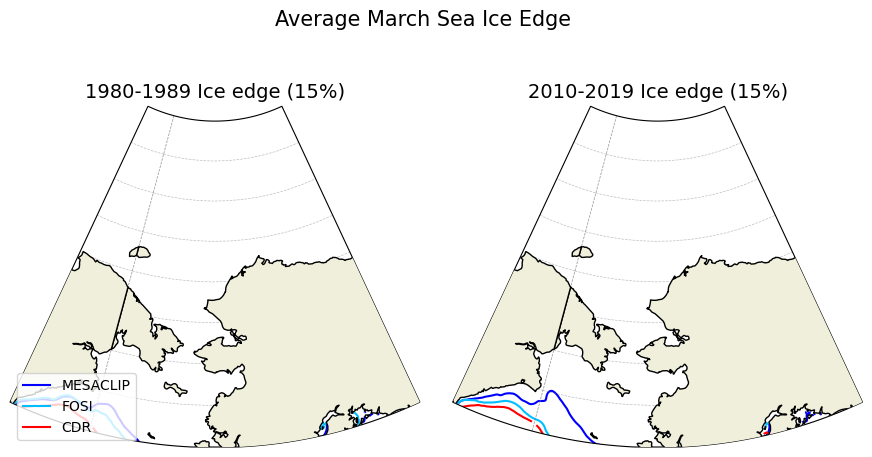

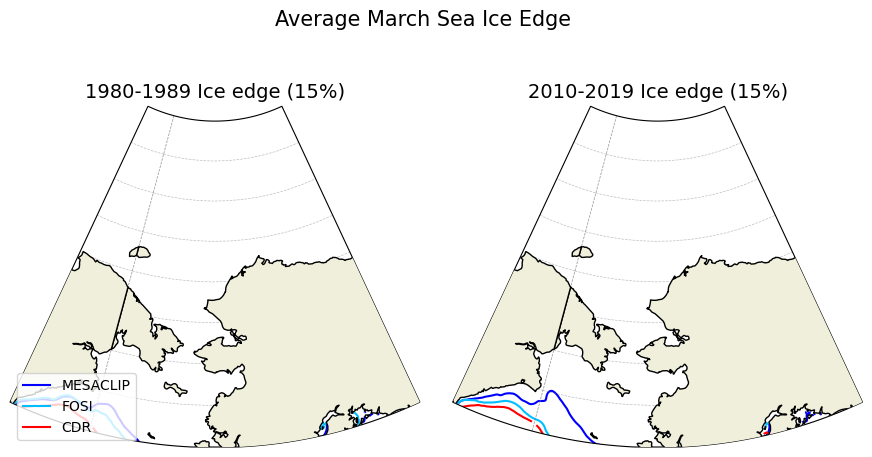

In [22]:
# march ice edges: earliest vs. latest decade, all 3 sources overlaid per panel
plot_ice_edges(
    "March",
    edge_sources=[
        (mesa_lon2d, mesa_lat2d, mesa_mar_decades, "blue", "MESACLIP"),
        (fosi_lon2d, fosi_lat2d, fosi_mar_decades, "deepskyblue", "FOSI"),
        (cdr_lon2d, cdr_lat2d, cdr_mar_decades, "red", "CDR"),
    ],
    fout="mesaclip_fosi_march_spatial_validation_ice_edges",
)

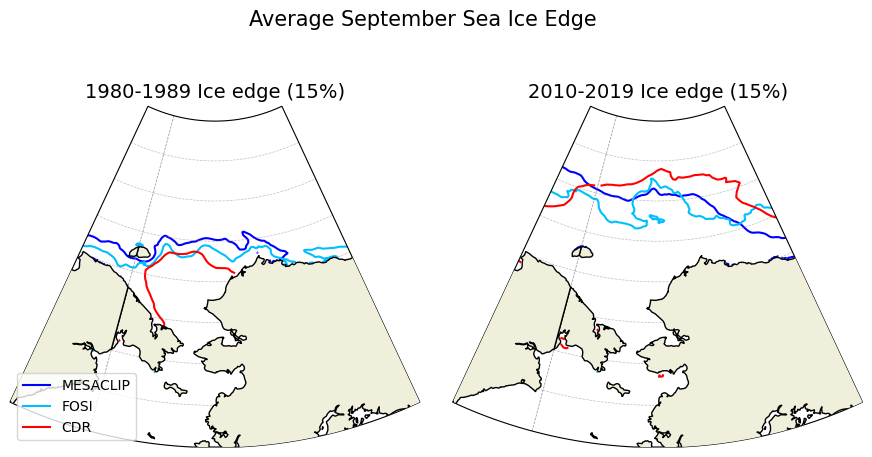

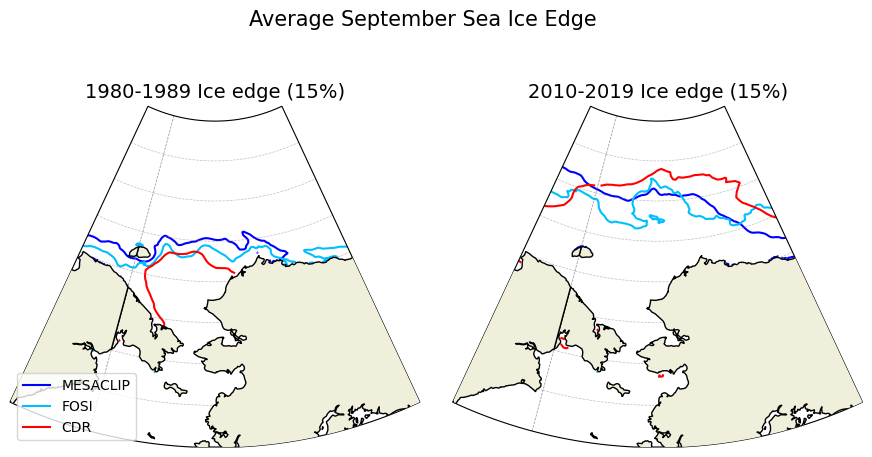

In [23]:
# september ice edges: earliest vs. latest decade, all 3 sources overlaid per panel
plot_ice_edges(
    "September",
    edge_sources=[
        (mesa_lon2d, mesa_lat2d, mesa_sep_decades, "blue", "MESACLIP"),
        (fosi_lon2d, fosi_lat2d, fosi_sep_decades, "deepskyblue", "FOSI"),
        (cdr_lon2d, cdr_lat2d, cdr_sep_decades, "red", "CDR"),
    ],
    fout="mesaclip_fosi_september_spatial_validation_ice_edges",
)